# 05 Classification: High-Price Listing Potential

Objective: classify whether a listing belongs to the high-price segment.

## 1. Imports and data loading

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import joblib
import json
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.modeling import build_preprocessor
from src.evaluation import classification_metrics

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / "modeling_airbnb_athens.csv")

df.head()

,id,name,host_id,host_since,host_is_superhost,host_response_rate,host_acceptance_rate,host_identity_verified,neighbourhood_cleansed,latitude,...,review_scores_location,review_scores_value,reviews_per_month,has_reviews,instant_bookable,is_entire_home,host_experience_days,estimated_occupancy_l365d,estimated_revenue_l365d,high_price_listing
0,33945,Spacious Cosy aprtm very close to Metro!,146553,2010-06-17,0.0,100.0,84.0,1.0,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,38.00673,...,4.64,4.81,0.49,1,0,1,5855.0,128,5760.0,0
1,49489,Ermou 44 - 3bdr apt in the heart of Athens,225612,2010-09-06,0.0,100.0,100.0,1.0,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.97670,...,4.89,4.69,0.83,1,1,1,5774.0,12,1920.0,1
2,60394,Cosy apartment! Great central Athens location!,290864,2010-11-18,1.0,NaN,100.0,1.0,ΣΤΑΔΙΟ,37.96738,...,4.92,4.92,0.29,1,0,1,5701.0,60,3000.0,0
3,154243,LUSCIOUS ROOF GARDEN IN THE CENTER!,741851,2011-06-25,0.0,60.0,77.0,1.0,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,37.98574,...,4.60,4.66,1.30,1,0,1,5482.0,84,5880.0,0
4,155654,"Acropolis Cosy Apartment, Koukaki",712602,2011-06-17,0.0,100.0,NaN,1.0,ΑΚΡΟΠΟΛΗ,37.96828,...,4.95,4.71,0.47,1,0,1,5490.0,0,0.0,0


In [2]:
df.shape

(14091, 45)

## 2. Check the target variable

In [3]:
df["high_price_listing"].value_counts()

high_price_listing
0    10555
1     3536
Name: count, dtype: int64

In [4]:
df["high_price_listing"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%"

high_price_listing
0    74.91%
1    25.09%
Name: proportion, dtype: object

# Classification Model: High-Price Listing Potential

The objective of this notebook is to classify whether an Airbnb listing belongs to the high-price segment. The target variable is `high_price_listing`, which equals 1 when the listing price is at or above the 75th percentile of the cleaned price distribution, and 0 otherwise.

This classification task is useful from a business intelligence perspective because it allows listings to be segmented into standard-price and high-price potential categories.

## 3. Define features and target

In [10]:
target = "high_price_listing"

numeric_features = [
    col for col in [
        "accommodates",
        "bathrooms",
        "bedrooms",
        "beds",
        "amenities_count",
        "minimum_nights",
        "maximum_nights",
        "availability_30",
        "availability_60",
        "availability_90",
        "availability_365",
        "availability_rate",
        "number_of_reviews",
        "number_of_reviews_ltm",
        "review_scores_rating",
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_value",
        "reviews_per_month",
        "host_experience_days",
        "host_response_rate",
        "host_acceptance_rate",
        "has_reviews"
    ] if col in df.columns
]

categorical_features = [
    col for col in [
        "neighbourhood_cleansed",
        "property_type",
        "room_type",
        "host_is_superhost",
        "host_identity_verified",
        "instant_bookable",
        "is_entire_home"
    ] if col in df.columns
]

features = numeric_features + categorical_features

model_df = df[features + [target]].dropna(subset=[target]).copy()

X = model_df[features]
y = model_df[target]

X.shape, y.shape

((14091, 33), (14091,))

## 4. Train/test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(high_price_listing
 0    0.749024
 1    0.250976
 Name: proportion, dtype: float64,
 high_price_listing
 0    0.749202
 1    0.250798
 Name: proportion, dtype: float64)

## 5. Train classification models

In [12]:
preprocessor = build_preprocessor(numeric_features, categorical_features)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    preds = pipe.predict(X_test)
    
    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(X_test)[:, 1]
    else:
        proba = None
    
    metrics = classification_metrics(y_test, preds, proba)
    metrics["Model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results)

metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
results_df[metric_cols] = results_df[metric_cols].round(3)

results_df = results_df.sort_values("ROC_AUC", ascending=False)

results_df

,Accuracy,Precision,Recall,F1,ROC_AUC,Model
1,0.853,0.827,0.526,0.643,0.899,Random Forest
2,0.846,0.778,0.542,0.639,0.882,Gradient Boosting
0,0.833,0.741,0.513,0.607,0.865,Logistic Regression


## Classification Model Results

The Random Forest Classifier achieved the best overall classification performance, with an accuracy of 0.853 and a ROC-AUC score of 0.899. This indicates that the model is highly effective at distinguishing high-price listings from standard-price listings.

The model also achieved high precision, at 0.827. This means that when the model predicts that a listing belongs to the high-price segment, it is usually correct. Recall is lower, at 0.526, meaning that the model identifies around half of the actual high-price listings.

This trade-off is acceptable for a business intelligence use case where the objective is to identify listings with strong high-price potential rather than capture every possible premium listing. If the business objective were to find as many premium listings as possible, the classification threshold could be adjusted to improve recall.

## 6. Save classification results

In [13]:
results_df.to_csv(REPORTS_DIR / "classification_model_results.csv", index=False)

print("Classification model results saved successfully.")

Classification model results saved successfully.


## 7. Select and save the best model

In [14]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipe.fit(X_train, y_train)

joblib.dump(best_pipe, MODELS_DIR / "best_high_price_classifier.pkl")

best_model_name

'Random Forest'

## Model Selection

The best classification model was selected based on ROC-AUC, because the task involves distinguishing high-price listings from standard-price listings. ROC-AUC is useful because it evaluates the model's ability to rank high-price listings higher than non-high-price listings across different classification thresholds.

## 8. Confusion matrix and classification report

In [15]:
best_preds = best_pipe.predict(X_test)
best_proba = best_pipe.predict_proba(X_test)[:, 1]

conf_matrix = confusion_matrix(y_test, best_preds)

conf_matrix

array([[2034,   78],
       [ 335,  372]])

In [16]:
print(classification_report(y_test, best_preds))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2112
           1       0.83      0.53      0.64       707

    accuracy                           0.85      2819
   macro avg       0.84      0.74      0.78      2819
weighted avg       0.85      0.85      0.84      2819



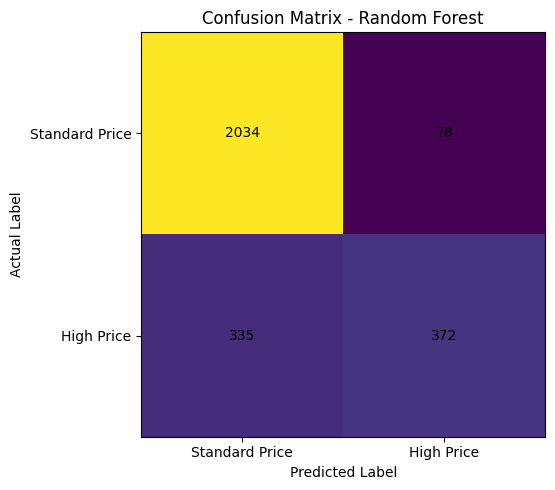

In [17]:
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Standard Price", "High Price"])
plt.yticks([0, 1], ["Standard Price", "High Price"])

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_confusion_matrix.png", dpi=300)
plt.show()

In [19]:
confusion_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["Actual Standard Price", "Actual High Price"],
    columns=["Predicted Standard Price", "Predicted High Price"]
)

confusion_matrix_df

,Predicted Standard Price,Predicted High Price
Actual Standard Price,2034,78
Actual High Price,335,372


## Confusion Matrix Interpretation

The confusion matrix shows that the Random Forest model correctly classified 2,034 standard-price listings and 372 high-price listings. The model incorrectly classified 78 standard-price listings as high-price and missed 335 actual high-price listings.

The classification report shows strong performance for standard-price listings, with a recall of 0.96 for class 0. This means that the model is highly effective at identifying listings that do not belong to the high-price segment.

For high-price listings, the model achieved a precision of 0.83 and a recall of 0.53. This means that when the model predicts a listing as high-price, it is usually correct, but it does not capture all high-price listings. In business terms, the model is conservative: it identifies high-price potential with high confidence, but some premium listings remain undetected.

This trade-off is acceptable for a BI portfolio project because the model can be used to highlight listings with strong high-price potential. If the business objective were to capture more high-price listings, the classification threshold could be adjusted to increase recall.

In [20]:
confusion_matrix_df.to_csv(
    REPORTS_DIR / "classification_confusion_matrix.csv"
)

print("Confusion matrix saved successfully.")

Confusion matrix saved successfully.


In [21]:
from sklearn.metrics import classification_report

classification_report_dict = classification_report(
    y_test,
    best_preds,
    output_dict=True
)

classification_report_df = pd.DataFrame(classification_report_dict).transpose()
classification_report_df = classification_report_df.round(3)

classification_report_df.to_csv(
    REPORTS_DIR / "classification_report.csv"
)

classification_report_df

,precision,recall,f1-score,support
0,0.859,0.963,0.908,2112.000
1,0.827,0.526,0.643,707.000
accuracy,0.853,0.853,0.853,0.853
macro avg,0.843,0.745,0.775,2819.000
weighted avg,0.851,0.853,0.841,2819.000


## 9. Create prediction output for Power BI

In [22]:
classification_predictions_df = X_test.copy()

classification_predictions_df["actual_high_price_listing"] = y_test.values
classification_predictions_df["predicted_high_price_listing"] = best_preds
classification_predictions_df["high_price_probability"] = best_proba

classification_predictions_df.head()

,accommodates,bathrooms,bedrooms,beds,amenities_count,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,...,neighbourhood_cleansed,property_type,room_type,host_is_superhost,host_identity_verified,instant_bookable,is_entire_home,actual_high_price_listing,predicted_high_price_listing,high_price_probability
5791,3,1.0,1.0,1.0,44,1,150,0,0,0,...,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,Entire condo,Entire home/apt,NaN,1.0,1,1,0,0,0.100000
2350,5,2.0,2.0,4.0,21,2,1125,7,29,57,...,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,Entire rental unit,Entire home/apt,0.0,1.0,0,1,1,1,0.666667
5176,2,1.5,1.0,1.0,41,3,365,0,5,33,...,ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ,Entire condo,Entire home/apt,1.0,1.0,0,1,0,0,0.076667
1780,5,1.0,1.0,3.0,58,1,1125,10,26,56,...,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,Entire condo,Entire home/apt,1.0,1.0,1,1,0,1,0.776667
11637,3,1.0,1.0,1.0,32,2,365,1,26,32,...,ΠΛΑΤΕΙΑ ΑΜΕΡΙΚΗΣ,Entire rental unit,Entire home/apt,1.0,1.0,1,1,0,0,0.170000


In [23]:
classification_predictions_df.to_csv(
    DATA_PROCESSED / "classification_predictions_airbnb_athens.csv",
    index=False
)

print("Classification prediction file saved successfully.")

Classification prediction file saved successfully.


## 10. Save model metrics as JSON

In [24]:
best_metrics = (
    results_df[results_df["Model"] == best_model_name]
    .drop(columns=["Model"])
    .iloc[0]
    .to_dict()
)

best_metrics = {k: round(float(v), 3) for k, v in best_metrics.items()}

with open(REPORTS_DIR / "classification_best_model_metrics.json", "w") as f:
    json.dump(best_metrics, f, indent=4)

best_metrics

{'Accuracy': 0.853,
 'Precision': 0.827,
 'Recall': 0.526,
 'F1': 0.643,
 'ROC_AUC': 0.899}

## Notebook 05 Summary

This notebook developed classification models to identify Airbnb listings with high-price potential in Athens. The target variable distinguishes listings at or above the 75th percentile of the cleaned price distribution.

The classification models provide a business-oriented segmentation layer that complements the regression model. While the regression model predicts nightly price, the classification model identifies whether a listing is likely to belong to the premium segment.

The final prediction file was saved for later use in the Power BI dashboard, where high-price probability can be visualised by neighbourhood, room type and property characteristics.